# EDA – Gym Exercises Dataset

## Objectif

Vérifier que le fichier gym_exercises_dataset.csv est correctement chargé et obtenir une vue d’ensemble :

• dimensions du jeu de données (nombre de lignes et de colonnes) ;  
• typage des variables (champs textuels, listes de muscles, attributs techniques) ;  
• premières observations sur les valeurs manquantes et la présence éventuelle de doublons ;  
• cohérence générale du corpus avant analyse statistique et préparation NLP.


## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

• la taille globale du dataset (nombre de lignes / colonnes) ;  
• la nature des variables (descriptifs textuels, attributs biomécaniques, catégories d’équipements) ;  
• la présence éventuelle de valeurs manquantes ou de champs textuels incomplets ;  
• l’existence (ou non) de doublons dans les données brutes ;  
• la cohérence générale des premières lignes (valeurs lisibles, descriptions complètes, muscles cohérents).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et préparer les étapes suivantes : nettoyage, normalisation textuelle et structuration pour le traitement NLP du projet TrAIn.me.

## Configuration notebook

### Importation des librairies essentielles

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import prince

from pathlib import Path
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


#### Configuration d’affichage et thème TrAIn.me


In [3]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [4]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


## Chargement et inspection initiale

Cette section vise à charger le fichier gym_exercises_dataset.csv, vérifier ses dimensions
et obtenir un premier aperçu des données brutes. Elle reprend la même démarche que pour
les autres EDA du projet : contrôle du chargement, visualisation des premières lignes,
statistiques descriptives de base, analyse des valeurs manquantes et des doublons, puis
liste complète des colonnes disponibles.


#### Chargement du dataset gym_exercises_dataset.csv


In [5]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("prajwaldongre/best-50-exercise-for-your-body")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


100%|██████████| 1.76k/1.76k [00:00<00:00, 1.80MB/s]

Extracting files...
Fichiers trouvés : ['Top 50 Excerice for your body.csv']
Dataset chargé avec succès !
Dimensions : 50 lignes et 8 colonnes



#### Aperçu des premières lignes


In [6]:
df.head(10)


,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level
0,Push-ups,3,15,Builds upper body strength,200,"Chest, Triceps, Shoulders",NaN,Intermediate
1,Squats,4,12,Strengthens lower body,223,"Quadriceps, Hamstrings, Glutes",NaN,Beginner
2,Lunges,3,10,Improves balance and coordination,275,"Quadriceps, Hamstrings, Glutes",NaN,Beginner
3,Burpees,3,10,Full body workout,355,Full Body,NaN,Advanced
4,Mountain Climbers,3,20,Improves cardiovascular fitness,240,"Core, Shoulders, Legs",NaN,Intermediate
5,Jumping Jacks,3,30,Improves coordination and cardiovascular health,295,Full Body,NaN,Beginner
6,Bicycle Crunches,3,20,Targets abdominal muscles,210,Core,NaN,Intermediate
7,Dips,3,12,Strengthens triceps and chest,180,"Triceps, Chest",Parallel Bars or Chair,Intermediate
8,Pull-ups,3,8,Builds upper body strength,250,"Back, Biceps",Pull-up Bar,Advanced
9,Russian Twists,3,20,Improves core rotation strength,190,"Core, Obliques",None or Dumbbell,Intermediate


#### Informations sur le typage, les valeurs manquantes et les doublons


In [7]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Name of Exercise             50 non-null     object
 1   Sets                         50 non-null     int64 
 2   Reps                         50 non-null     int64 
 3   Benefit                      50 non-null     object
 4   Burns Calories (per 30 min)  50 non-null     int64 
 5   Target Muscle Group          50 non-null     object
 6   Equipment Needed             30 non-null     object
 7   Difficulty Level             50 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.3+ KB


### Statistiques descriptives des variables numériques

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0


### Analyse des valeurs manquantes et doublons

In [9]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


Equipment Needed               20
Name of Exercise                0
Sets                            0
Reps                            0
Benefit                         0
Burns Calories (per 30 min)     0
Target Muscle Group             0
Difficulty Level                0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


#### Liste complète des colonnes disponibles


In [10]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())



--- Liste des colonnes du dataset ---
['Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']


## Statistiques descriptives et distribution des variables

Cette section analyse la distribution des variables numériques du dataset, identifie les
ordres de grandeur, met en évidence les valeurs extrêmes éventuelles et prépare les
étapes suivantes de détection d’outliers et de corrélation.


#### Objectif

- Résumer la distribution des variables numériques (moyenne, médiane, étendue).
- Observer la dispersion et la variabilité des mesures.
- Identifier d'éventuelles valeurs extrêmes ou atypiques.
- Préparer la détection d’outliers (boxplots, IQR).


#### Interprétation attendue

À l’issue de cette section, l’analyse devra mettre en évidence :

- les valeurs centrales des variables clés (nombre de séries, nombre de répétitions, calories brûlées) pour caractériser l’intensité moyenne des exercices ;
- la dispersion et la variabilité des mesures (écarts-types, min/max, quartiles), permettant d’identifier des exercices plus « légers » ou nettement plus exigeants ;
- la présence éventuelle de valeurs extrêmes ou atypiques (par exemple nombre de répétitions très élevé ou dépense calorique particulièrement importante) qui pourront faire l’objet d’un traitement spécifique ;
- les premiers ordres de grandeur utiles pour le projet TrAIn.me (plages typiques de volume d’entraînement et de dépense énergétique), en vue de préparer la recommandation d’exercices adaptés au profil de l’utilisateur.


#### Statistiques descriptives globales


In [12]:
# --- Colonnes numériques du dataset ---
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques détectées ({len(num_cols)}) : {num_cols}")

# Statistiques descriptives de base
stats_num = df[num_cols].describe().T
display(stats_num)

# Quelques repères métier
if "Sets" in df.columns:
    print(f"\nNombre moyen de séries : {df['Sets'].mean():.2f}")

if "Reps" in df.columns:
    print(f"Nombre moyen de répétitions : {df['Reps'].mean():.2f}")

if "Burns Calories (per 30 min)" in df.columns:
    print(f"Calories moyennes brûlées en 30 min : {df['Burns Calories (per 30 min)'].mean():.0f} kcal")


Variables numériques détectées (3) : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


,count,mean,std,min,25%,50%,75%,max
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0



Nombre moyen de séries : 3.12
Nombre moyen de répétitions : 12.78
Calories moyennes brûlées en 30 min : 230 kcal


#### Distribution des variables clés


Variables représentées : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


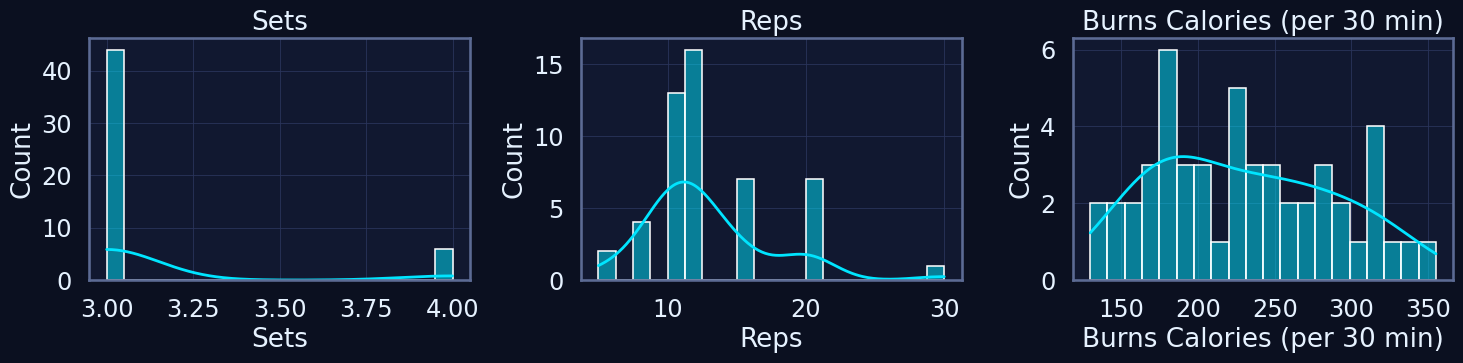

In [13]:
# Sélection des variables numériques réellement pertinentes
num_vars = num_cols  # toutes les variables numériques sont métier ici
print(f"Variables représentées : {num_vars}")

n = len(num_vars)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Boxplots pour repérer les outliers


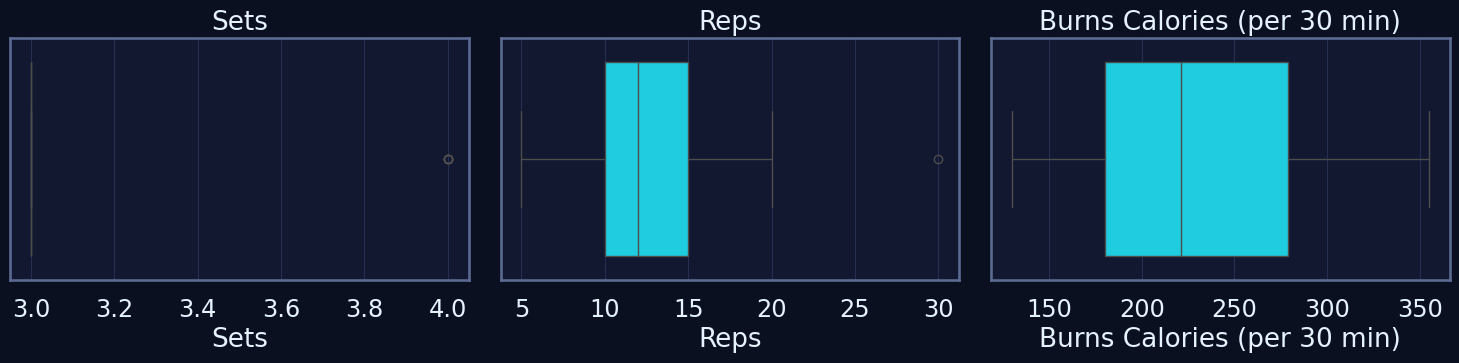

In [14]:
plt.figure(figsize=(5 * len(num_vars), 4))

for i, col in enumerate(num_vars, 1):
    plt.subplot(1, len(num_vars), i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.grid(True, axis="x")

plt.tight_layout()
plt.show()


#### Statistiques descriptives enrichies


In [15]:
if num_cols:
    desc = df[num_cols].describe().T
    desc["missing_%"] = df[num_cols].isna().mean() * 100
    desc["zeros_%"] = (df[num_cols] == 0).mean() * 100
    desc["skew"] = df[num_cols].skew()
    desc["kurt"] = df[num_cols].kurt()

    display(desc.sort_values("std", ascending=False))
else:
    print("ℹ️ Aucune variable numérique disponible pour des statistiques enrichies.")


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0,0.0,0.0,0.274614,-0.949834
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0,0.0,0.0,1.379863,3.070059
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0,0.0,0.0,2.411701,3.973747


#### Détection rapide d’outliers (IQR)


In [16]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])

iqr_df.sort_values("outliers", ascending=False)


,outliers
Sets,6
Reps,1
Burns Calories (per 30 min),0


#### Aperçu corrélations (sous-ensemble lisible)


C:\Users\fback\AppData\Local\Temp\ipykernel_40392\4255799464.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


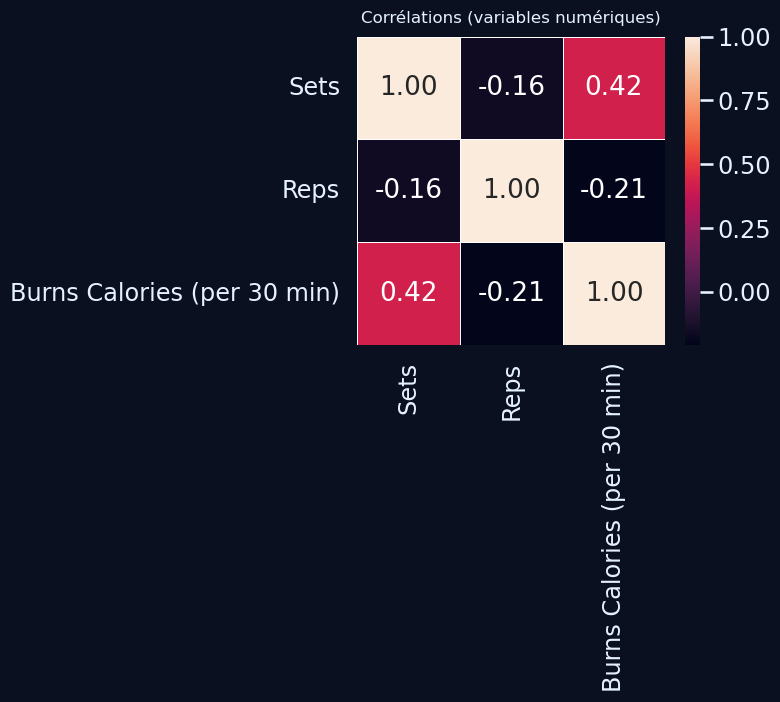

In [17]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
        linewidths=0.5,
    )
    plt.title("Corrélations (variables numériques)", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Corrélation non pertinente : une seule variable numérique disponible.")


## Visualisation univariée

Cette section complète les statistiques descriptives par une analyse visuelle des distributions
des variables numériques. L’objectif est de vérifier la forme des distributions (symétrie,
concentration, valeurs extrêmes) pour les principales mesures d’intensité des exercices.


#### Objectif

- Visualiser la répartition des variables numériques (Sets, Reps, Burns Calories).
- Identifier les niveaux les plus fréquents et les éventuels déséquilibres.
- Repérer visuellement des valeurs extrêmes ou atypiques.
- Préparer les décisions de nettoyage ou de regroupement pour la suite de l’analyse.


#### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- décrire la forme des distributions (exercices plutôt modérés ou fortement concentrés
  autour de certaines valeurs de séries, de répétitions ou de calories brûlées) ;
- signaler la présence éventuelle de niveaux très peu représentés ou de valeurs extrêmes ;
- confirmer les ordres de grandeur observés (volume d’entraînement et dépense énergétique
  typiques) ;
- fournir des éléments visuels pour classer les exercices selon leur intensité globale,
  en préparation des futures étapes de recommandation.


#### Sélection robuste des variables numériques à visualiser


In [19]:
# --- Sélection des variables numériques pertinentes pour la visualisation univariée ---

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numériques détectées :", num_cols)

# Dans ce dataset, toutes les variables numériques sont métier (volume & intensité)
vars_univariate = num_cols.copy()

print("Variables retenues pour la visualisation univariée :", vars_univariate)


Variables numériques détectées : ['Sets', 'Reps', 'Burns Calories (per 30 min)']
Variables retenues pour la visualisation univariée : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


#### Visualisation des distributions univariées (hist + KDE)


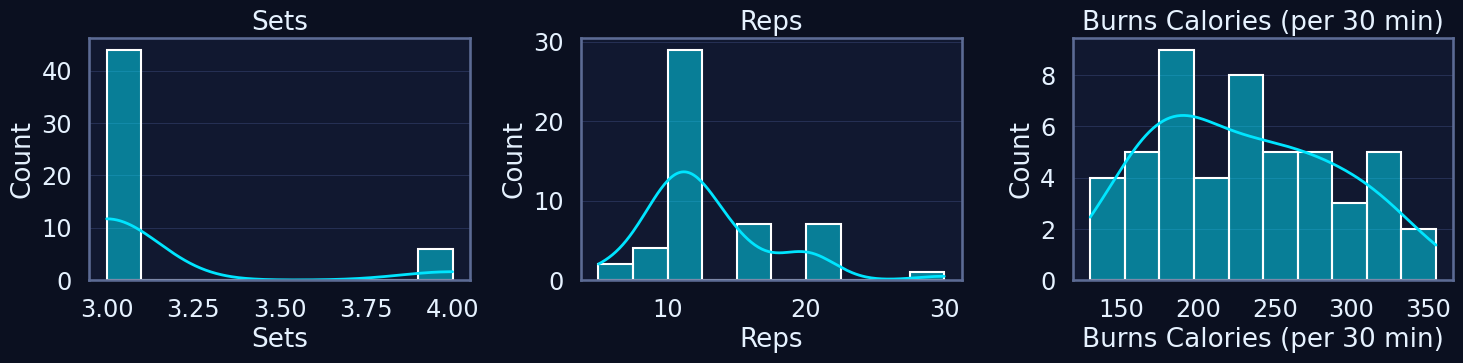

In [20]:
if not vars_univariate:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n = len(vars_univariate)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=10, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


#### Boxplots univariés pour détection visuelle d’outliers


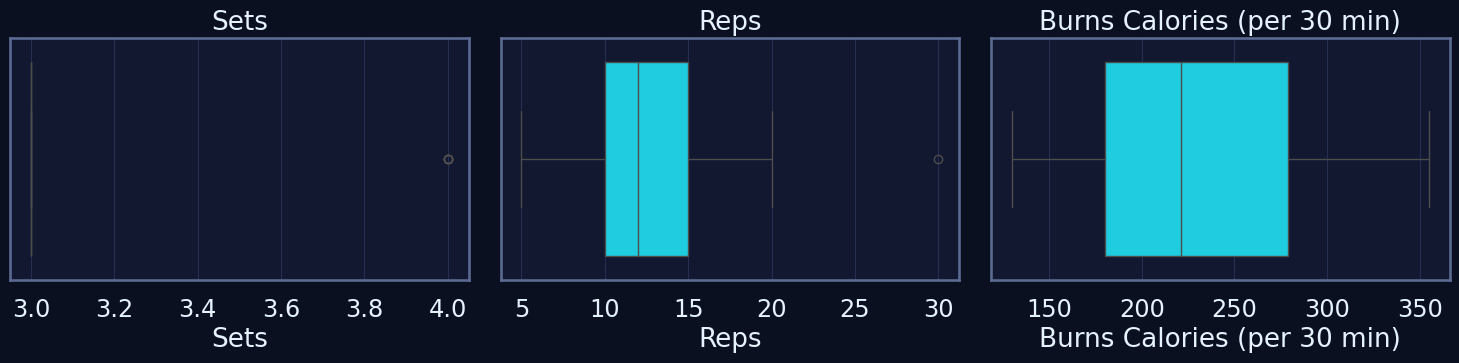

In [21]:
if not vars_univariate:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")
else:
    plt.figure(figsize=(5 * len(vars_univariate), 4))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(1, len(vars_univariate), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()
